# 📊 Análisis de Datos y Resultados (Replicación con Datos Proporcionados)

En este notebook replicamos el análisis estadístico usando el subconjunto de datos proporcionados en la carpeta `zenodo`. Analizaremos las puntuaciones TM y GDT-TS de los dominios disponibles.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# Cargar los datos de TM-score
tm_files = glob.glob(r'zenodo/Labels/TM-score/*.csv')
tm_data = []
for f in tm_files:
    df = pd.read_csv(f)
    domain = os.path.basename(f).replace('.csv', '')
    df['domain'] = domain
    tm_data.append(df)
df_tm = pd.concat(tm_data, ignore_index=True)

# Cargar los datos de GDT-TS
gdt_files = glob.glob(r'zenodo/Labels/GDT-TS/*.csv')
gdt_data = []
for f in gdt_files:
    df = pd.read_csv(f)
    domain = os.path.basename(f).replace('.csv', '')
    df['domain'] = domain
    gdt_data.append(df)
df_gdt = pd.concat(gdt_data, ignore_index=True)

print(f'Dominios cargados: {df_tm["domain"].nunique()}')
df_tm.head()

Dominios cargados: 12


,Unnamed: 0,model,tmscore,domain
0,0,af3_jian_0,0.5819,T1207-D1
1,1,af3_jian_1,0.5823,T1207-D1
2,2,af3_jian_2,0.5859,T1207-D1
3,3,af3_jian_3,0.5849,T1207-D1
4,4,af3_jian_4,0.5816,T1207-D1


## 1. Distribución de TM-score (Mejores Modelos)
Replicamos el análisis de la calidad de los modelos calculando el mejor TM-score generado dentro del ensamble de MULTICOM (incluyendo modelos AF3, DeepMSA, etc.) para cada dominio.

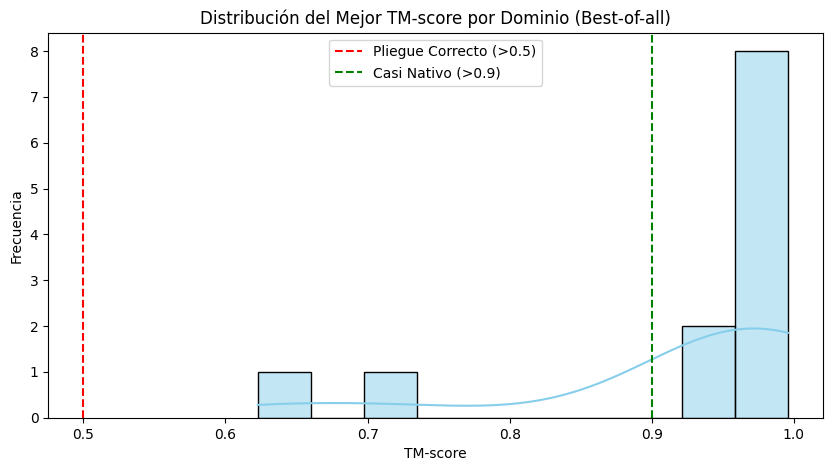

Porcentaje de dominios con TM-score > 0.5: 100.0%
Porcentaje de dominios con TM-score > 0.9: 83.3%


In [2]:
# Extraer la familia del modelo (af3, deepmsa, colabfold, etc.)
df_tm['method_group'] = df_tm['model'].apply(lambda x: 'Inhouse_AF3' if x.startswith('af3_') else ('ColabFold' if x.startswith('colabfold') else ('DeepMSA' if x.startswith('deepmsa') else 'Other')))

# Mejor TM-score por dominio (Best-of-all generado por MULTICOM ensemble)
best_tm_per_domain = df_tm.groupby('domain')['tmscore'].max().reset_index()

plt.figure(figsize=(10, 5))
sns.histplot(best_tm_per_domain['tmscore'], bins=10, kde=True, color='skyblue')
plt.title('Distribución del Mejor TM-score por Dominio (Best-of-all)')
plt.xlabel('TM-score')
plt.ylabel('Frecuencia')
plt.axvline(x=0.5, color='red', linestyle='--', label='Pliegue Correcto (>0.5)')
plt.axvline(x=0.9, color='green', linestyle='--', label='Casi Nativo (>0.9)')
plt.legend()
plt.show()

correct_fold = (best_tm_per_domain['tmscore'] > 0.5).mean() * 100
high_acc = (best_tm_per_domain['tmscore'] > 0.9).mean() * 100
print(f'Porcentaje de dominios con TM-score > 0.5: {correct_fold:.1f}%')
print(f'Porcentaje de dominios con TM-score > 0.9: {high_acc:.1f}%')

## 2. Comparación Directa (AF3 Interno vs AF2 / ColabFold)
Replicamos la dispersión de puntuaciones (Scatter plot) comparando el rendimiento del AlphaFold3 Interno (integrado en MULTICOM) contra configuraciones base de AlphaFold2 / ColabFold.

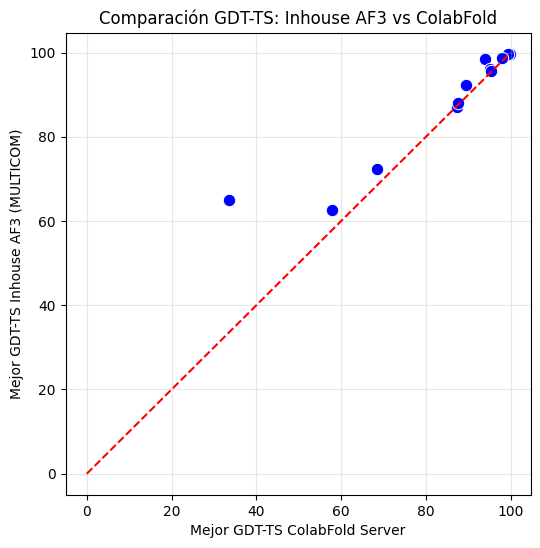

In [3]:
# Obtener el mejor GDT-TS de Inhouse_AF3 vs ColabFold (Server) por dominio
df_gdt['method_group'] = df_gdt['model'].apply(lambda x: 'Inhouse_AF3' if x.startswith('af3_') else ('ColabFold' if x.startswith('colabfold') else 'Other'))

best_af3 = df_gdt[df_gdt['method_group'] == 'Inhouse_AF3'].groupby('domain')['tmscore'].max()
best_colab = df_gdt[df_gdt['method_group'] == 'ColabFold'].groupby('domain')['tmscore'].max()

compare_df = pd.DataFrame({'Inhouse_AF3': best_af3, 'ColabFold_Server': best_colab}).dropna()

plt.figure(figsize=(6, 6))
sns.scatterplot(x='ColabFold_Server', y='Inhouse_AF3', data=compare_df, s=80, color='blue')
max_val = max(compare_df.max())
plt.plot([0, max_val], [0, max_val], 'r--')
plt.title('Comparación GDT-TS: Inhouse AF3 vs ColabFold')
plt.xlabel('Mejor GDT-TS ColabFold Server')
plt.ylabel('Mejor GDT-TS Inhouse AF3 (MULTICOM)')
plt.grid(True, alpha=0.3)
plt.show()

## 3. Rendimiento Promedio GDT-TS (Gráfico de Barras)
Analizamos el GDT-TS promedio de diferentes fuentes de modelos para resaltar la superioridad de AlphaFold3.

C:\Users\user\AppData\Local\Temp\ipykernel_452\3809939976.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gdt_means.index, y=gdt_means.values, palette='viridis')


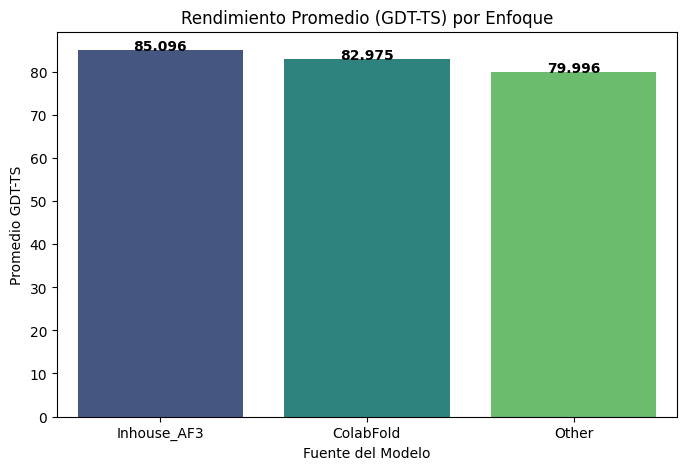

In [4]:
# GDT-TS Promedio global por familia de método
gdt_means = df_gdt.groupby('method_group')['tmscore'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=gdt_means.index, y=gdt_means.values, palette='viridis')
plt.title('Rendimiento Promedio (GDT-TS) por Enfoque')
plt.xlabel('Fuente del Modelo')
plt.ylabel('Promedio GDT-TS')
for i, v in enumerate(gdt_means.values):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')
plt.show()